In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date, timedelta
import sys


pd.set_option('display.width', None)  # let it use full terminal width
pd.set_option('display.max_columns', None)  # show all columns
pd.set_option('display.expand_frame_repr', False)  # don't wrap to multiple blocks

print(sys.executable)

c:\Users\ethan\Projects\mlops-weather-forecast\.venv\Scripts\python.exe


# 1) Pull and Inspect Raw Data

In [6]:
# Pull a full year of daily weather data — Cape Town
# Uses the Historical Weather API (archive-api), NOT /v1/forecast:
# /v1/forecast only serves ~16 days of forecast, not a full year of history.
# ERA5 reanalysis data (which the archive API is built on) has a ~5 day
# processing delay, so end_date can't be today — pull up to 7 days ago to be safe.
end_date = date.today() - timedelta(days=7)
start_date = end_date - timedelta(days=365 * 10)

response = requests.get("https://archive-api.open-meteo.com/v1/archive", params={
    "latitude": -25.8589,
    "longitude": 28.1858,
    "daily": [
        "temperature_2m_max",
        "temperature_2m_min",
        "apparent_temperature_max",

        "precipitation_sum",
        "precipitation_hours",

        "wind_speed_10m_max",  
        "wind_speed_10m_mean",
        "wind_direction_10m_dominant",    # note: underscore between "wind" and "speed"
        "shortwave_radiation_sum",
    ],
    "start_date": start_date.isoformat(),
    "end_date": end_date.isoformat(),
    "timezone": "Africa/Johannesburg",
})

response.raise_for_status()   # throws an error if the API call failed

In [7]:
df = pd.DataFrame(response.json()["daily"])
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df['time'].min()} → {df['time'].max()}")
print(df.head())

Shape: (3651, 10)
Date range: 2016-07-27 00:00:00 → 2026-07-25 00:00:00
        time  temperature_2m_max  temperature_2m_min  apparent_temperature_max  precipitation_sum  precipitation_hours  wind_speed_10m_max  wind_speed_10m_mean  wind_direction_10m_dominant  shortwave_radiation_sum
0 2016-07-27                13.2                -0.2                       8.9                0.0                  0.0                13.1                 10.0                          244                    17.55
1 2016-07-28                16.0                -0.7                      11.9                0.0                  0.0                14.2                  9.3                          250                    17.24
2 2016-07-29                18.0                 2.3                      14.3                0.0                  0.0                13.0                 10.3                          193                    17.21
3 2016-07-30                19.4                 3.3                    

# 2) Understand the Data Quality

=== Missing Values ===
time                           0
temperature_2m_max             0
temperature_2m_min             0
apparent_temperature_max       0
precipitation_sum              0
precipitation_hours            0
wind_speed_10m_max             0
wind_speed_10m_mean            0
wind_direction_10m_dominant    0
shortwave_radiation_sum        0
dtype: int64

=== Basic Statistics ===
                                time  temperature_2m_max  temperature_2m_min  apparent_temperature_max  precipitation_sum  precipitation_hours  wind_speed_10m_max  wind_speed_10m_mean  wind_direction_10m_dominant  shortwave_radiation_sum
count                           3651         3651.000000         3651.000000               3651.000000        3651.000000          3651.000000         3651.000000          3651.000000                  3651.000000              3651.000000
mean   2021-07-25 23:59:59.999999744           23.990852           12.077267                 22.854122           1.784333           

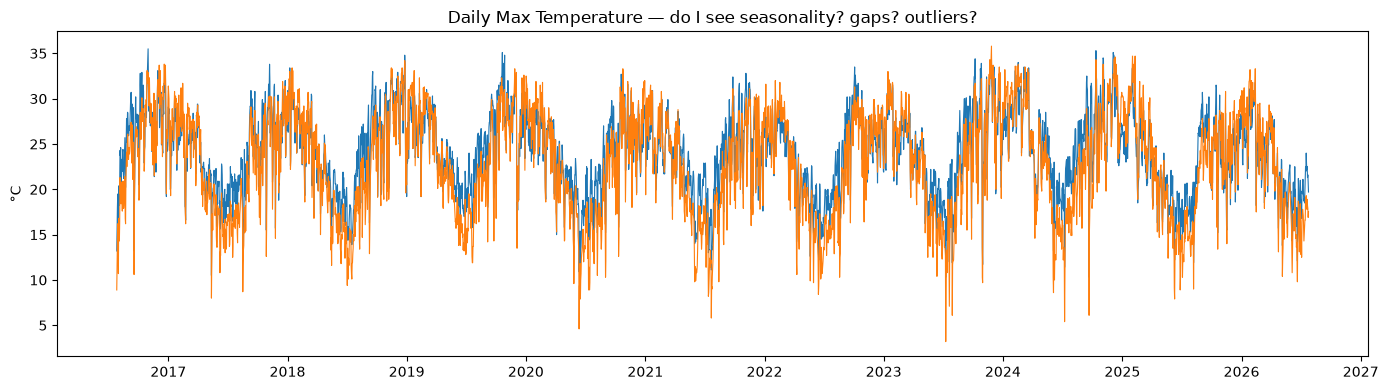

In [8]:
print("=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
print(df.describe())

# Plot the target variable — what are we predicting?
plt.figure(figsize=(14, 4))
plt.plot(df["time"], df["temperature_2m_max"], linewidth=0.8)
plt.plot(df["time"], df["apparent_temperature_max"], linewidth=0.8)
plt.title("Daily Max Temperature — do I see seasonality? gaps? outliers?")
plt.ylabel("°C")
plt.tight_layout()
plt.show()

# 3) Build Candidate Features

In [9]:
df_feat = df.copy().sort_values("time").reset_index(drop=True)

# Lag features — yesterday's values predict tomorrow
# You MUST shift before computing lags to prevent data leakage
for lag in [1, 2, 3]:
    df_feat[f"tmax_lag{lag}"] = df_feat["temperature_2m_max"].shift(lag)
    df_feat[f"tmin_lag{lag}"] = df_feat["temperature_2m_min"].shift(lag)
    df_feat[f"apparentmax_lag{lag}"] = df_feat["apparent_temperature_max"].shift(lag)
    df_feat[f"precip_lag{lag}"] = df_feat["precipitation_sum"].shift(lag)
    df_feat[f"preciphours_lag{lag}"] = df_feat["precipitation_hours"].shift(lag)

# Rolling stats — smooth out noise, capture trends
# .shift(1) BEFORE .rolling() — critical to not leak today's value into the window
df_feat["tmax_roll2_mean"] = df_feat["temperature_2m_max"].shift(1).rolling(2).mean()
df_feat["tmax_roll2_std"]  = df_feat["temperature_2m_max"].shift(1).rolling(2).std()
df_feat["tmax_roll3_mean"] = df_feat["temperature_2m_max"].shift(1).rolling(3).mean()
df_feat["tmax_roll3_std"]  = df_feat["temperature_2m_max"].shift(1).rolling(3).std()

# Calendar features — capture seasonality
df_feat["day_of_year"] = df_feat["time"].dt.dayofyear
df_feat["month"]       = df_feat["time"].dt.month
df_feat["week"]        = df_feat["time"].dt.isocalendar().week.astype(int)

# Pass-through features from the raw data
# windspeed and radiation are already daily aggregates, use as-is
# (they are already lag-safe since they are measured the same day, not tomorrow)

# Target: NEXT day's max temperature
# Shift by -1 so that for each row, target = what we want to predict
df_feat["target"] = df_feat["temperature_2m_max"].shift(-1)

# Drop rows where we can't form complete features OR target
df_clean = df_feat.dropna().reset_index(drop=True)
print(f"Rows after dropping NaN: {len(df_clean)} (lost {len(df_feat)-len(df_clean)} to lag/rolling warmup)")
df_clean.head()

Rows after dropping NaN: 3647 (lost 4 to lag/rolling warmup)


,time,temperature_2m_max,temperature_2m_min,apparent_temperature_max,precipitation_sum,precipitation_hours,wind_speed_10m_max,wind_speed_10m_mean,wind_direction_10m_dominant,shortwave_radiation_sum,tmax_lag1,tmin_lag1,apparentmax_lag1,precip_lag1,preciphours_lag1,tmax_lag2,tmin_lag2,apparentmax_lag2,precip_lag2,preciphours_lag2,tmax_lag3,tmin_lag3,apparentmax_lag3,precip_lag3,preciphours_lag3,tmax_roll2_mean,tmax_roll2_std,tmax_roll3_mean,tmax_roll3_std,day_of_year,month,week,target
0,2016-07-30,19.4,3.3,16.2,0.0,0.0,14.2,9.5,170,17.28,18.0,2.3,14.3,0.0,0.0,16.0,-0.7,11.9,0.0,0.0,13.2,-0.2,8.9,0.0,0.0,17.00,1.414214,15.733333,2.411086,212,7,30,19.5
1,2016-07-31,19.5,5.7,15.4,0.0,0.0,21.9,16.5,44,16.71,19.4,3.3,16.2,0.0,0.0,18.0,2.3,14.3,0.0,0.0,16.0,-0.7,11.9,0.0,0.0,18.70,0.989949,17.800000,1.708801,213,7,30,15.5
2,2016-08-01,15.5,4.1,10.7,0.0,0.0,20.8,12.4,194,17.36,19.5,5.7,15.4,0.0,0.0,19.4,3.3,16.2,0.0,0.0,18.0,2.3,14.3,0.0,0.0,19.45,0.070711,18.966667,0.838650,214,8,31,19.2
3,2016-08-02,19.2,4.3,16.8,0.0,0.0,14.8,9.9,101,17.50,15.5,4.1,10.7,0.0,0.0,19.5,5.7,15.4,0.0,0.0,19.4,3.3,16.2,0.0,0.0,17.50,2.828427,18.133333,2.281082,215,8,31,20.4
4,2016-08-03,20.4,3.3,14.5,0.0,0.0,26.6,15.9,258,17.34,19.2,4.3,16.8,0.0,0.0,15.5,4.1,10.7,0.0,0.0,19.5,5.7,15.4,0.0,0.0,17.35,2.616295,18.066667,2.227854,216,8,31,18.2


In [10]:
df_clean.columns

Index(['time', 'temperature_2m_max', 'temperature_2m_min',
       'apparent_temperature_max', 'precipitation_sum', 'precipitation_hours',
       'wind_speed_10m_max', 'wind_speed_10m_mean',
       'wind_direction_10m_dominant', 'shortwave_radiation_sum', 'tmax_lag1',
       'tmin_lag1', 'apparentmax_lag1', 'precip_lag1', 'preciphours_lag1',
       'tmax_lag2', 'tmin_lag2', 'apparentmax_lag2', 'precip_lag2',
       'preciphours_lag2', 'tmax_lag3', 'tmin_lag3', 'apparentmax_lag3',
       'precip_lag3', 'preciphours_lag3', 'tmax_roll2_mean', 'tmax_roll2_std',
       'tmax_roll3_mean', 'tmax_roll3_std', 'day_of_year', 'month', 'week',
       'target'],
      dtype='object')

# 4) Feature Selection — Which Features Actually Help?

In [11]:
from sklearn.ensemble import GradientBoostingRegressor

# Define all candidates you created above
candidate_features = ['temperature_2m_max', 'temperature_2m_min',
       'apparent_temperature_max', 'precipitation_sum', 'precipitation_hours',
       'wind_speed_10m_max', 'wind_speed_10m_mean',
       'wind_direction_10m_dominant', 'shortwave_radiation_sum', 'tmax_lag1',
       'tmin_lag1', 'apparentmax_lag1', 'precip_lag1', 'preciphours_lag1',
       'tmax_lag2', 'tmin_lag2', 'apparentmax_lag2', 'precip_lag2',
       'preciphours_lag2', 'tmax_lag3', 'tmin_lag3', 'apparentmax_lag3',
       'precip_lag3', 'preciphours_lag3', 'tmax_roll2_mean', 'tmax_roll2_std',
       'tmax_roll3_mean', 'tmax_roll3_std', 'day_of_year', 'month', 'week',
]

X_all = df_clean[candidate_features]
y     = df_clean["target"]

# Quick correlation check — which features are linearly related to the target?
correlations = X_all.corrwith(y).abs().sort_values(ascending=False)
print("Correlation with target:\n", correlations)

Correlation with target:
 temperature_2m_max             0.842939
apparent_temperature_max       0.824265
apparentmax_lag1               0.729803
tmax_lag1                      0.715659
tmax_roll2_mean                0.710686
tmax_roll3_mean                0.707462
shortwave_radiation_sum        0.699830
temperature_2m_min             0.685728
apparentmax_lag2               0.670821
tmax_lag2                      0.648809
apparentmax_lag3               0.635615
tmax_lag3                      0.611933
tmin_lag1                      0.611609
tmin_lag2                      0.574879
tmin_lag3                      0.555980
day_of_year                    0.111762
week                           0.109955
month                          0.109817
precipitation_sum              0.100356
precipitation_hours            0.089583
preciphours_lag3               0.076192
wind_speed_10m_mean            0.056711
preciphours_lag2               0.044976
tmax_roll3_std                 0.043332
precip_lag1   

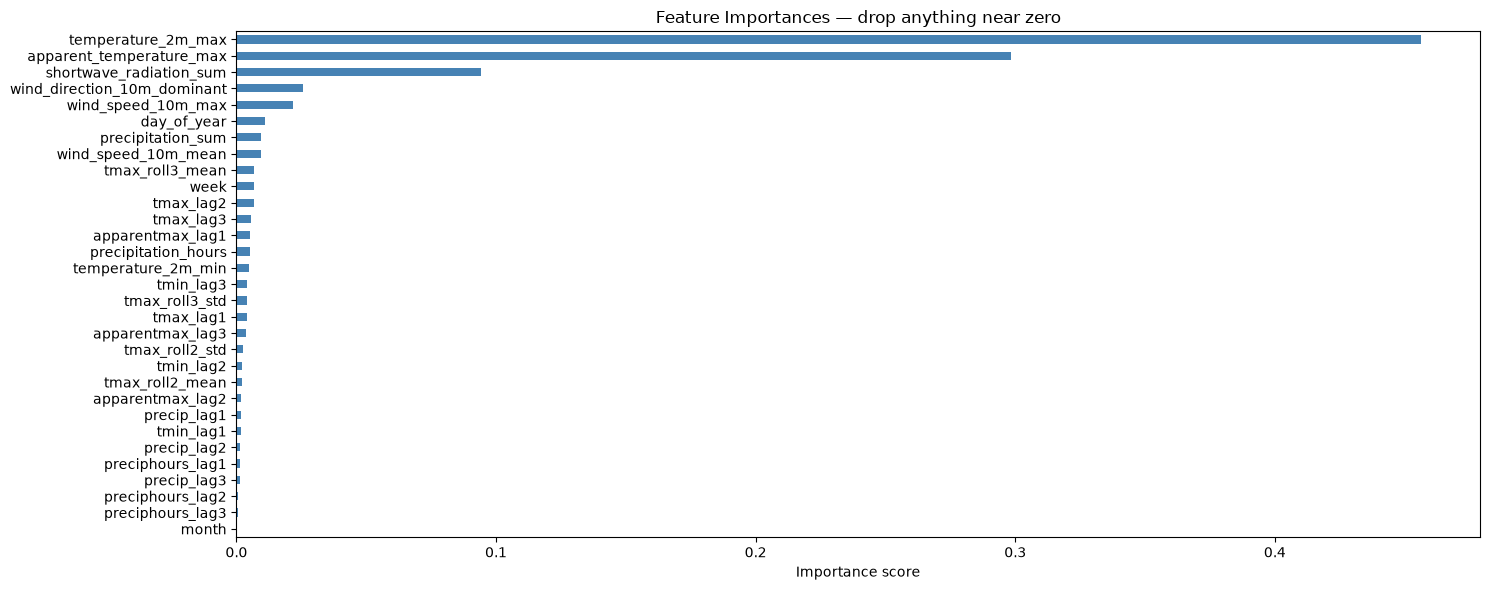


Lowest importance features (candidates to drop):
month               0.000001
preciphours_lag3    0.000543
preciphours_lag2    0.000640
precip_lag3         0.001221
preciphours_lag1    0.001304
precip_lag2         0.001416
tmin_lag1           0.001590
precip_lag1         0.001698
apparentmax_lag2    0.001702
tmax_roll2_mean     0.002153
dtype: float64


In [12]:
# Train a quick model on ALL features and look at importances
quick_model = GradientBoostingRegressor(n_estimators=200, random_state=74)
quick_model.fit(X_all, y)

importances = pd.Series(quick_model.feature_importances_, index=candidate_features)
importances.sort_values().plot(kind="barh", figsize=(15, 6), color="steelblue")
plt.title("Feature Importances — drop anything near zero")
plt.xlabel("Importance score")
plt.tight_layout()
plt.show()

# Print the bottom ones explicitly
print("\nLowest importance features (candidates to drop):")
print(importances.sort_values().head(10))

# 5) Compare Algorithms

In [13]:
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import numpy as np

# The FINAL feature list — after dropping weak ones above
# Edit this based on what you saw in cell 4
final_features = ['temperature_2m_max', 'temperature_2m_min', 'apparent_temperature_max', 'precipitation_sum', 'wind_speed_10m_max', 'wind_speed_10m_mean', 'wind_direction_10m_dominant', 'shortwave_radiation_sum', 'tmax_lag1',
                  'tmin_lag1', 'apparentmax_lag1', 'precip_lag1', 'tmax_lag2', 'tmin_lag2', 'apparentmax_lag2', 'precip_lag2', 'tmax_lag3', 'tmin_lag3', 'apparentmax_lag3', 'precip_lag3',  'tmax_roll2_mean', 'tmax_roll2_std',
                  'tmax_roll3_mean', 'tmax_roll3_std', 'day_of_year', 'month', 'week',]

X = df_clean[final_features]
y = df_clean["target"]

# TimeSeriesSplit is critical — never use regular KFold on time series data
# Regular KFold shuffles randomly, so fold 3 could train on data from the future
# TimeSeriesSplit always trains on past, validates on future — mirrors real deployment
tscv = TimeSeriesSplit(n_splits=10)

models_to_try = {
    "Ridge":  Ridge(),
    "RF":     RandomForestRegressor(n_estimators=100, random_state=7),
    "GBM":    GradientBoostingRegressor(n_estimators=100, random_state=7),
    "MLP":    MLPRegressor(hidden_layer_sizes=(100, 100), activation="relu", random_state=7, max_iter=500)
}

print("Algorithm comparison (CV MAE ± std):")
results = {}
for name, model in models_to_try.items():
    scores = cross_val_score(
        model, X, y, cv=tscv, scoring="neg_mean_absolute_error"
    )
    mae_mean = -scores.mean()
    mae_std  = scores.std()
    results[name] = mae_mean
    print(f"  {name:8s}: {mae_mean:.3f}°C ± {mae_std:.3f}")

winner = min(results, key=results.get)
print(f"\nWinner: {winner}")
# → This tells you which algorithm goes into config.yaml

Algorithm comparison (CV MAE ± std):
  Ridge   : 1.703°C ± 0.086
  RF      : 1.689°C ± 0.151
  GBM     : 1.664°C ± 0.135
  MLP     : 1.788°C ± 0.110

Winner: GBM


# 6) Tune Winning Algo

In [14]:
from sklearn.model_selection import GridSearchCV

# GBM won (most likely). Now find the best hyperparameters.
param_grid = {
    "n_estimators":  [80, 100, 200, 300],
    "max_depth":     [3, 4, 5, 6],
    "learning_rate": [0.001, 0.01,0.025,0.03, 0.05, 0.1],
    "max_features": ["sqrt", 0.8],
}

grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X, y)

print(f"\nBest params:  {grid_search.best_params_}")
print(f"Best CV MAE:  {-grid_search.best_score_:.3f}°C")

# EXAMPLE OUTPUT (your numbers will differ slightly):
# Best params:  {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}
# Best CV MAE:  1.698°C
#
# ↑ These go directly into config.yaml under model.params
# ↑ This is where the "model parameter values" come from

Fitting 10 folds for each of 192 candidates, totalling 1920 fits

Best params:  {'learning_rate': 0.025, 'max_depth': 4, 'max_features': 'sqrt', 'n_estimators': 300}
Best CV MAE:  1.641°C


# 7) Final Holdout Validation

Holdout MAE: 1.669°C
Holdout R²:  0.754


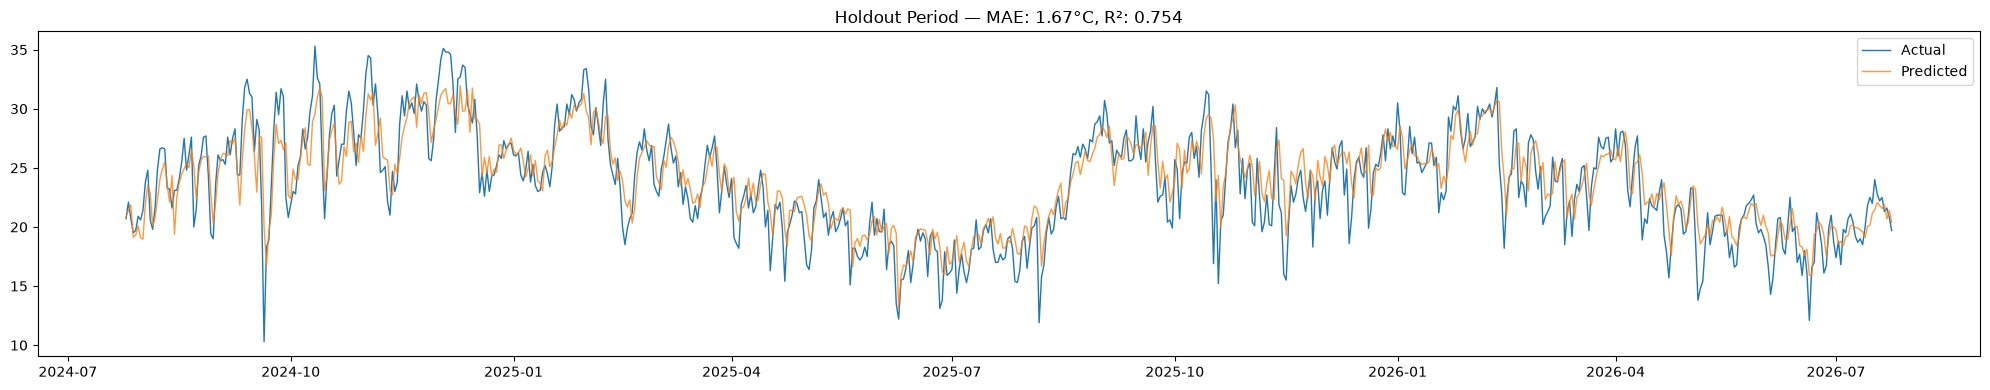


→ Set config.yaml mae_threshold to approximately: 2.2


In [15]:
from sklearn.metrics import mean_absolute_error, r2_score

# Simulate what will happen in production:
# Train on historical data, evaluate on the most recent unseen data
# Use a genuine time-based split — last 20% of dates for holdout
cutoff = int(len(df_clean) * 0.80)

X_train = df_clean[final_features].iloc[:cutoff]
X_test  = df_clean[final_features].iloc[cutoff:]
y_train = df_clean["target"].iloc[:cutoff]
y_test  = df_clean["target"].iloc[cutoff:]

best_params = grid_search.best_params_
final_model = GradientBoostingRegressor(**best_params, random_state=42)
final_model.fit(X_train, y_train)
preds = final_model.predict(X_test)

holdout_mae = mean_absolute_error(y_test, preds)
holdout_r2  = r2_score(y_test, preds)

print(f"Holdout MAE: {holdout_mae:.3f}°C")
print(f"Holdout R²:  {holdout_r2:.3f}")

# Plot actual vs predicted on the holdout period
test_dates = df_clean["time"].iloc[cutoff:]
plt.figure(figsize=(20, 4))
plt.plot(test_dates, y_test.values, label="Actual", linewidth=1)
plt.plot(test_dates, preds,         label="Predicted", linewidth=1, alpha=0.8)
plt.title(f"Holdout Period — MAE: {holdout_mae:.2f}°C, R²: {holdout_r2:.3f}")
plt.legend()
plt.tight_layout()
plt.show()

# The holdout MAE is what you set as mae_threshold in config.yaml
# Because: a freshly retrained model on new data should at least match
# the performance you saw during experimentation
print(f"\n→ Set config.yaml mae_threshold to approximately: {holdout_mae + 0.5:.1f}")
# Adding 0.5°C buffer — allows a slightly worse model to still pass the gate

In [16]:
print(grid_search.estimator)
print(grid_search.best_params_)

GradientBoostingRegressor(random_state=42)
{'learning_rate': 0.025, 'max_depth': 4, 'max_features': 'sqrt', 'n_estimators': 300}


# 8) Log Experiment to Mlflow 

In [54]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("weather-forecast")

with mlflow.start_run(run_name="notebook-experimentation"):
    mlflow.log_params(best_params)
    mlflow.log_param("features_used", len(final_features))
    mlflow.log_metric("holdout_mae", holdout_mae)
    mlflow.log_metric("holdout_r2",  holdout_r2)
    mlflow.log_metric("cv_mae", -grid_search.best_score_)

    # Log the final model — not registering it yet (that's for the pipeline)
    mlflow.sklearn.log_model(final_model, name="model")

    print("Logged to MLflow ✓")
    print("Open http://127.0.0.1:5000 to see this run")

2026/07/06 23:42:06 INFO mlflow.tracking.fluent: Experiment with name 'weather-forecast' does not exist. Creating a new experiment.
2026/07/06 23:42:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged to MLflow ✓
Open http://127.0.0.1:5000 to see this run
🏃 View run notebook-experimentation at: http://127.0.0.1:5000/#/experiments/1/runs/502d08ea58f1464a800efafd43fb86a9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
